# Notebook 02 — Baseline TF-IDF

Notre premier modèle : on utilise TF-IDF (comptage de mots pondéré) + similarité cosinus pour scorer les paires CV/offre. C'est le score à battre avec le deep learning.

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

from src.data_utils import load_dataset_fit, group_split

df = load_dataset_fit()
train_df, test_df = group_split(df)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Dataset chargé: 8000 paires
Colonnes: ['resume_text', 'job_description_text', 'label']
CVs uniques: 643 pour 8000 paires
Train: 6595 | Test: 1405
Overlap CVs train/test: 0 (doit être 0)
Train: 6595 | Test: 1405


## TF-IDF Vectorisation

In [10]:
# on fit le vectorizer sur tous les textes du train (CVs + offres ensemble)
all_train_texts = pd.concat([train_df['resume_text'], train_df['job_description_text']]).tolist()
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf.fit(all_train_texts)

print(f"Vocabulaire: {len(tfidf.vocabulary_)} termes")

# encoder les paires
train_cv_vectors = tfidf.transform(train_df['resume_text'])
train_job_vectors = tfidf.transform(train_df['job_description_text'])
test_cv_vectors = tfidf.transform(test_df['resume_text'])
test_job_vectors = tfidf.transform(test_df['job_description_text'])

Vocabulaire: 10000 termes


## Cosine Similarity

Scores train — min: 0.0000, max: 0.4183, mean: 0.0778
Scores test  — min: 0.0020, max: 0.3383, mean: 0.0746


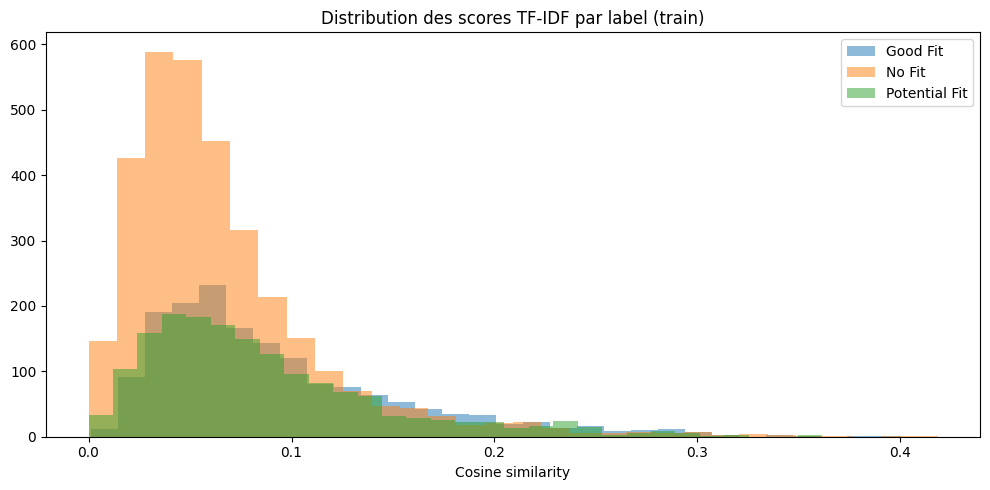

In [11]:
# calculer la similarité cosinus pour chaque paire
# attention: cosine_similarity retourne une matrice, on veut juste la diagonale
train_scores = np.array([
    cosine_similarity(train_cv_vectors[i], train_job_vectors[i])[0][0]
    for i in range(len(train_df))
])
test_scores = np.array([
    cosine_similarity(test_cv_vectors[i], test_job_vectors[i])[0][0]
    for i in range(len(test_df))
])

print(f"Scores train — min: {train_scores.min():.4f}, max: {train_scores.max():.4f}, mean: {train_scores.mean():.4f}")
print(f"Scores test  — min: {test_scores.min():.4f}, max: {test_scores.max():.4f}, mean: {test_scores.mean():.4f}")

# distribution des scores par label
fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(train_df['label'].unique()):
    mask = train_df['label'] == label
    ax.hist(train_scores[mask], bins=30, alpha=0.5, label=label)
ax.set_title('Distribution des scores TF-IDF par label (train)')
ax.set_xlabel('Cosine similarity')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/tfidf_score_distribution.png', dpi=150)
plt.show()

## Calibration des seuils

On cherche les meilleurs seuils pour classifier les scores en 3 classes. Grid search simple sur le train set.

In [12]:
# on cherche les meilleurs seuils sur le train set
# 2 seuils : high_thresh (au-dessus = Good Fit) et low_thresh (en-dessous = No Fit)
best_f1 = 0
best_thresholds = (0.5, 0.3)

# grid search simple
for high in np.arange(0.1, 0.9, 0.02):
    for low in np.arange(0.05, high, 0.02):
        preds = []
        for s in train_scores:
            if s >= high:
                preds.append("Good Fit")
            elif s >= low:
                preds.append("Potential Fit")
            else:
                preds.append("No Fit")
        
        f1 = f1_score(train_df['label'], preds, average='weighted', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresholds = (high, low)

high_thresh, low_thresh = best_thresholds
print(f"\nMeilleurs seuils trouvés sur le train:")
print(f"  Good Fit si score >= {high_thresh:.2f}")
print(f"  Potential Fit si score >= {low_thresh:.2f}")
print(f"  No Fit sinon")
print(f"  F1 train: {best_f1:.4f}")


Meilleurs seuils trouvés sur le train:
  Good Fit si score >= 0.12
  Potential Fit si score >= 0.07
  No Fit sinon
  F1 train: 0.4599


## Évaluation sur le test set

In [13]:
def classify_tfidf(scores, high_thresh, low_thresh):
    preds = []
    for s in scores:
        if s >= high_thresh:
            preds.append("Good Fit")
        elif s >= low_thresh:
            preds.append("Potential Fit")
        else:
            preds.append("No Fit")
    return preds

test_preds = classify_tfidf(test_scores, high_thresh, low_thresh)

f1 = f1_score(test_df['label'], test_preds, average='weighted')
acc = accuracy_score(test_df['label'], test_preds)

print(f"=== Résultats TF-IDF sur le TEST set ===")
print(f"F1 weighted: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"\nClassification report:")
print(classification_report(test_df['label'], test_preds))

=== Résultats TF-IDF sur le TEST set ===
F1 weighted: 0.4726
Accuracy: 0.4819

Classification report:
               precision    recall  f1-score   support

     Good Fit       0.38      0.24      0.29       336
       No Fit       0.60      0.66      0.63       716
Potential Fit       0.30      0.35      0.32       353

     accuracy                           0.48      1405
    macro avg       0.43      0.42      0.42      1405
 weighted avg       0.47      0.48      0.47      1405



## Matrice de confusion

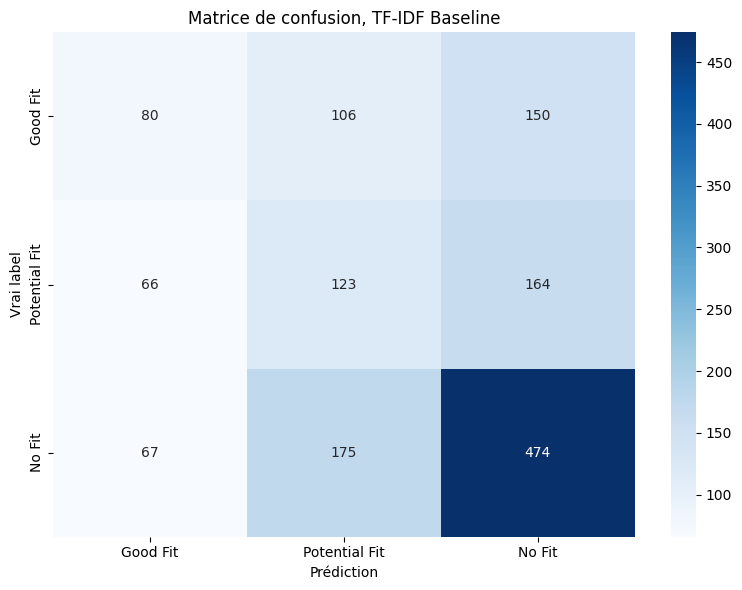

In [14]:
labels = ["Good Fit", "Potential Fit", "No Fit"]
cm = confusion_matrix(test_df['label'], test_preds, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Matrice de confusion, TF-IDF Baseline')
ax.set_ylabel('Vrai label')
ax.set_xlabel('Prédiction')
plt.tight_layout()
plt.savefig('../figures/tfidf_confusion_matrix.png', dpi=150)
plt.show()

## Récap

In [ ]:
# tableau récapitulatif
print("=" * 50)
print("BASELINE TF-IDF — RÉSULTATS")
print("=" * 50)
print(f"Méthode: TF-IDF + Cosine Similarity")
print(f"Vocabulaire: {len(tfidf.vocabulary_)} termes")
print(f"Seuils: Good Fit >= {high_thresh:.2f}, Potential Fit >= {low_thresh:.2f}")
print(f"")
print(f"F1 weighted:  {f1:.4f}")
print(f"Accuracy:     {acc:.4f}")
print(f"")
print(f"C'est le score à battre avec les modèles deep learning.")
print(f"Prochaine étape: sentence-transformers pré-entraînés")

BASELINE TF-IDF — RÉSULTATS
Méthode: TF-IDF + Cosine Similarity
Vocabulaire: 10000 termes
Seuils: Good Fit >= 0.12, Potential Fit >= 0.07

F1 weighted:  0.4726
Accuracy:     0.4819

C'est le score à battre avec les modèles deep learning.
Prochaine étape: sentence-transformers pré-entraînés (notebook 03)
